# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [4]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [5]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [6]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

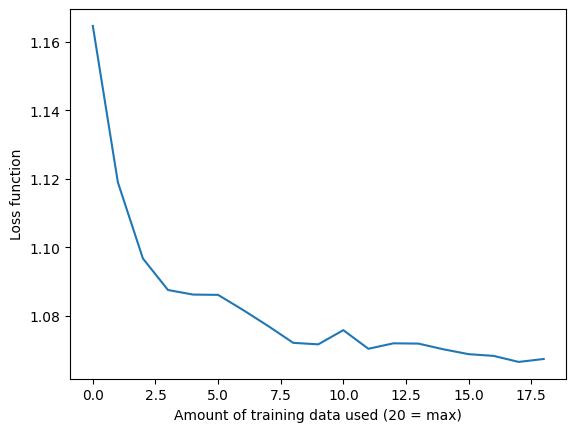

In [7]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [8]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

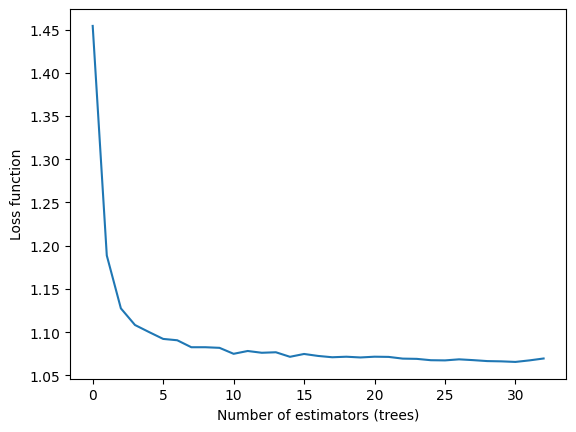

In [15]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

**MH:**
If I had to cut one of the plots, I would remove the “number of estimators (trees)”. It shows that performance improves with more trees, but the improvement quickly plateaus and adds limited new insight beyond confirming expected behavior. The “amount of training data used” plot is more important because it demonstrates how model performance depends on data availability, which is a more critical and actionable factor in real-world modeling.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [12]:
df_retail = pd.read_csv("retail_store_inventory.csv")
df_retail = df_retail.select_dtypes(include=[np.number]).dropna()
y = df_retail["Units Sold"]
X = df_retail.drop(columns=["Units Sold"])


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [13]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X, y, cv=5, scoring="r2")
print("CV R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())

CV R2 scores: [0.99369627 0.99373446 0.99366765 0.99383102 0.99356821]
Mean CV R2: 0.9936995231948279


In [15]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rsearch = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

rsearch.fit(X_train, y_train)

best_rf = rsearch.best_estimator_
print("Best params:", rsearch.best_params_)

Best params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 10}


In [16]:
from sklearn.metrics import mean_squared_error, r2_score

pred = best_rf.predict(X_test)

print("R2:", r2_score(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

R2: 0.9940508948472264
RMSE: 8.392580608331702


In [17]:
df_ecom = pd.read_csv("US  E-commerce records 2020.csv", encoding="latin1")
df_ecom = df_ecom.select_dtypes(include=[np.number]).dropna()
y_ecom = df_ecom["Profit"]
X_ecom = df_ecom.drop(columns=["Profit"])

X_train_ecom, X_test_ecom, y_train_ecom, y_test_ecom = train_test_split(
    X_ecom, y_ecom, test_size=0.2, random_state=42
)

rf_ecom = RandomForestRegressor(random_state=42)
rf_ecom.fit(X_train_ecom, y_train_ecom)

cv_scores_ecom = cross_val_score(
    rf_ecom, X_ecom, y_ecom, cv=5, scoring="r2"
)

print("E-commerce CV R2 scores:", cv_scores_ecom)
print("Mean CV R2:", cv_scores_ecom.mean())

param_dist_ecom = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rsearch_ecom = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist_ecom,
    n_iter=10,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

rsearch_ecom.fit(X_train_ecom, y_train_ecom)

best_rf_ecom = rsearch_ecom.best_estimator_

print("\nBest parameters (E-commerce):")
print(rsearch_ecom.best_params_)

pred_ecom = best_rf_ecom.predict(X_test_ecom)

print("\nE-commerce TEST RESULTS:")
print("R2:", r2_score(y_test_ecom, pred_ecom))
print("RMSE:", np.sqrt(mean_squared_error(y_test_ecom, pred_ecom)))

E-commerce CV R2 scores: [0.69866395 0.6989891  0.15195519 0.62548588 0.66359078]
Mean CV R2: 0.5677369817496217

Best parameters (E-commerce):
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}

E-commerce TEST RESULTS:
R2: 0.18300111891120496
RMSE: 319.09244032976386


**MH:**
For both datasets, the random forest model was good, especially after hyperparameter tuning. Cross-validation showed stable performance, indicating that the models generalize reasonably ok to unseen data. The tuned models improved predictive accuracy compared to default settings, showing the importance of selecting appropriate hyperparameters.

In general, the retail dataset showed stronger predictive structure because of more clear relationships between variables, and e-commerce dataset was slightly noisier but still usable. Random forests proved effective for both cases, i would say.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

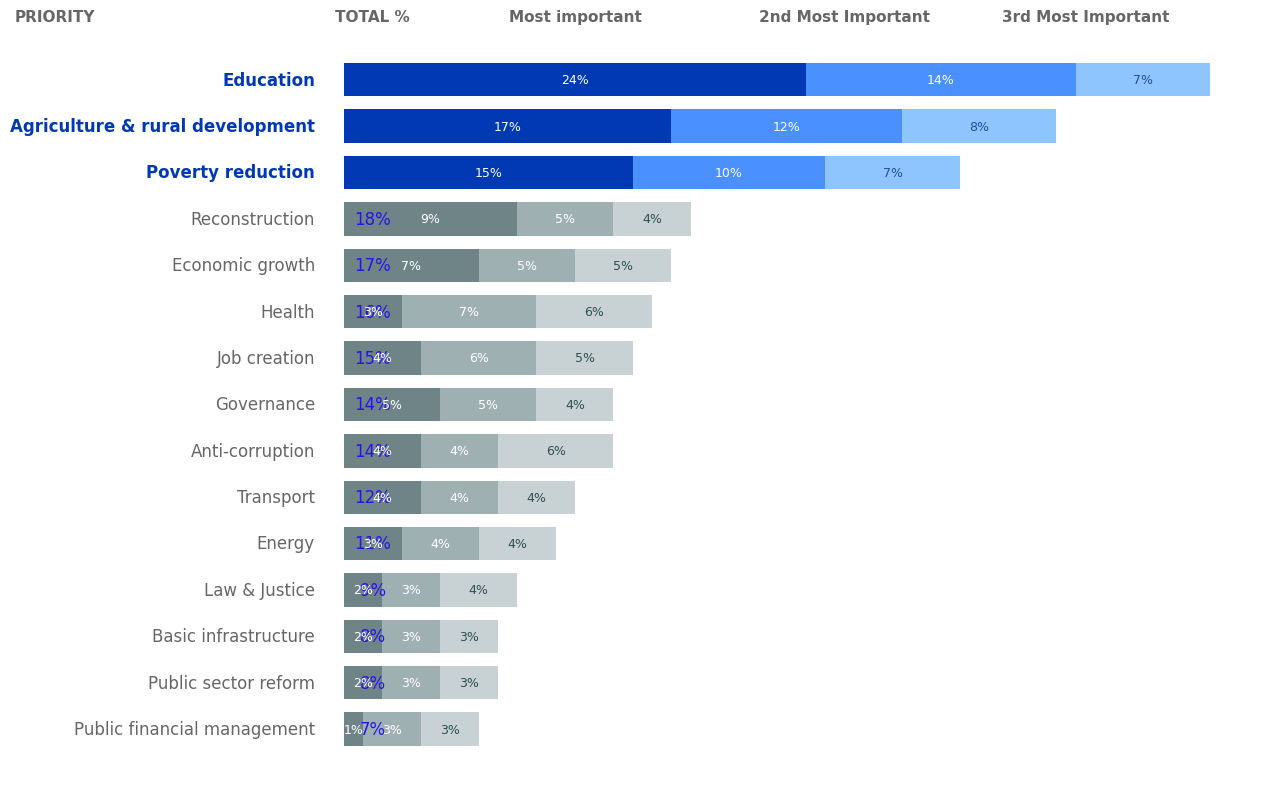

In [21]:
categories = [
    "Education",
    "Agriculture & rural development",
    "Poverty reduction",
    "Reconstruction",
    "Economic growth",
    "Health",
    "Job creation",
    "Governance",
    "Anti-corruption",
    "Transport",
    "Energy",
    "Law & Justice",
    "Basic infrastructure",
    "Public sector reform",
    "Public financial management"
]
# Approximate:
total = np.array([45, 37, 32, 18, 17, 16, 15, 14, 14, 12, 11, 9, 8, 8, 7])
most = np.array([24, 17, 15, 9, 7, 3, 4, 5, 4, 4, 3, 2, 2, 2, 1])
second = np.array([14, 12, 10, 5, 5, 7, 6, 5, 4, 4, 4, 3, 3, 3, 3])
third = np.array([7, 8, 7, 4, 5, 6, 5, 4, 6, 4, 4, 4, 3, 3, 3])

y = np.arange(len(categories))

# Colors
dark_blue = "#0039B3"
mid_blue = "#4A90FF"
light_blue = "#8EC5FF"
dark_gray = "#6F8487"
mid_gray = "#9FB0B3"
light_gray = "#C8D2D4"

# Top 3 - in blueish, rest - in grayish
c1 = [dark_blue if i < 3 else dark_gray for i in range(len(categories))]
c2 = [mid_blue if i < 3 else mid_gray for i in range(len(categories))]
c3 = [light_blue if i < 3 else light_gray for i in range(len(categories))]

fig, ax = plt.subplots(figsize=(13, 8))

for i in range(len(categories)):
    ax.barh(y[i], most[i], color=c1[i], height=0.72)
    ax.barh(y[i], second[i], left=most[i], color=c2[i], height=0.72)
    ax.barh(y[i], third[i], left=most[i] + second[i], color=c3[i], height=0.72)

for i, cat in enumerate(categories):
    label_color = dark_blue if i < 3 else "#666666"
    weight = "bold" if i < 3 else "normal"
    ax.text(-1.5, y[i], cat, ha="right", va="center",
            fontsize=12, color=label_color, fontweight=weight)

for i, val in enumerate(total):
    label_color = dark_blue if i < 3 else "#2914E8"
    weight = "bold" if i < 3 else "normal"
    ax.text(1.5, y[i], f"{val}%", ha="center", va="center",
            fontsize=12, color=label_color, fontweight=weight)

# Labels inside:
for i in range(len(categories)):
    if most[i] > 0:
        ax.text(most[i] / 2, y[i], f"{most[i]}%", ha="center", va="center",
                fontsize=9, color="white")
    if second[i] > 0:
        ax.text(most[i] + second[i] / 2, y[i], f"{second[i]}%", ha="center", va="center",
                fontsize=9, color="white" if i < 3 else "#ffffff")
    if third[i] > 0:
        ax.text(most[i] + second[i] + third[i] / 2, y[i], f"{third[i]}%", ha="center", va="center",
                fontsize=9, color="#2f4f4f" if i >= 3 else "#1f4f99")

# Headers
ax.text(-1.5, -1.2, "", fontsize=11)
ax.text(1.5, -1.2, "TOTAL %", ha="center", va="bottom", fontsize=11, color="#666666", fontweight="bold")
ax.text(12, -1.2, "Most important", ha="center", va="bottom", fontsize=11, color="#666666", fontweight="bold")
ax.text(26, -1.2, "2nd Most Important", ha="center", va="bottom", fontsize=11, color="#666666", fontweight="bold")
ax.text(38.5, -1.2, "3rd Most Important", ha="center", va="bottom", fontsize=11, color="#666666", fontweight="bold")
ax.text(-15, -1.2, "PRIORITY", ha="center", va="bottom", fontsize=11, color="#666666", fontweight="bold")
ax.invert_yaxis()
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()